In [1]:
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sc.set_figure_params(figsize=(8, 8))

Global seed set to 0


In [2]:
adata = sc.read_h5ad('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/rna/mapping/scVI_test/anndata.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 147203 × 15403
    obs: 'sample', 'stage', 'celltype', 'origin'
    var: 'name'

In [4]:
# preprocessing
sc.pp.filter_genes(adata, min_counts=3)
adata.layers["counts"] = adata.X.copy() # preserve counts
adata.raw = adata # freeze the state in `.raw`

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2500,
    subset=True,
    layer="counts",
    flavor="cell_ranger",
    batch_key="origin"
)

/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:510: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.highly_variable.iloc[:n_top_genes] = True


#### Figure out how to do the batch/covariate correction
how to compare stage with day of in vitro
what are the batches vs covariates? 
maybe if I make the day of in vitro a stage column it will automatically batch correct both the origin and the timepoint
|

# Test 1

In [5]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="stage",
    categorical_covariate_keys=["sample"]
)

INFO     Using batches from adata.obs["stage"]                                               
INFO     No label_key inputted, assuming all cells have same label                           
INFO     Using data from adata.layers["counts"]                                              
INFO     Successfully registered anndata object containing 147203 cells, 2500 vars, 14       
         batches, 1 labels, and 0 proteins. Also registered 1 extra categorical covariates   
         and 0 extra continuous covariates.                                                  
INFO     Please do not further modify adata until model is trained.                          


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:315: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [6]:
model = scvi.model.SCVI(adata, n_latent=40)

In [ ]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 25/54:  44%|████▍     | 24/54 [1:11:31<1:26:52, 173.74s/it, loss=1.03e+03, v_num=1]

In [ ]:
model.save("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/rna/mapping/scVI_test/scvi_model_try1/")

In [5]:
model = scvi.model.SCVI.load("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/rna/mapping/scVI_test/scvi_model_try1/", adata)

INFO     .obs[_scvi_labels] not found in target, assuming every cell is same category        
INFO     Using data from adata.layers["counts"]                                              


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/model/base/_utils.py:84: UserWarning: var_names for adata passed in does not match var_names of adata used to train the model. For valid results, the vars need to be the same and in the same order as the adata used to train the model.
  warnings.warn(
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function transfer_anndata_setup is deprecated; This method will be removed in 0.15.0. Please avoid building any new dependencies on it.
  warnings.warn(msg, category=FutureWarning)


INFO     Registered keys:['X', 'batch_indices', 'labels', 'cat_covs']                        
INFO     Successfully registered anndata object containing 147203 cells, 2500 vars, 14       
         batches, 1 labels, and 0 proteins. Also registered 1 extra categorical covariates   
         and 0 extra continuous covariates.                                                  


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:315: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [6]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent
# adata.layers["scvi_normalized"] = model.get_normalized_expression(
#     library_size=10e4
# )

In [7]:
adata.obs.tail()

,sample,stage,celltype,origin,_scvi_batch,_scvi_labels
cell_99994,29,E8.5,Pharyngeal_mesoderm,atlas,12,0
cell_99995,29,E8.5,Forebrain_Midbrain_Hindbrain,atlas,12,0
cell_99997,29,E8.5,Erythroid3,atlas,12,0
cell_99998,29,E8.5,ExE_endoderm,atlas,12,0
cell_99999,29,E8.5,Intermediate_mesoderm,atlas,12,0


In [8]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=35)
sc.tl.umap(adata, min_dist=0.4)

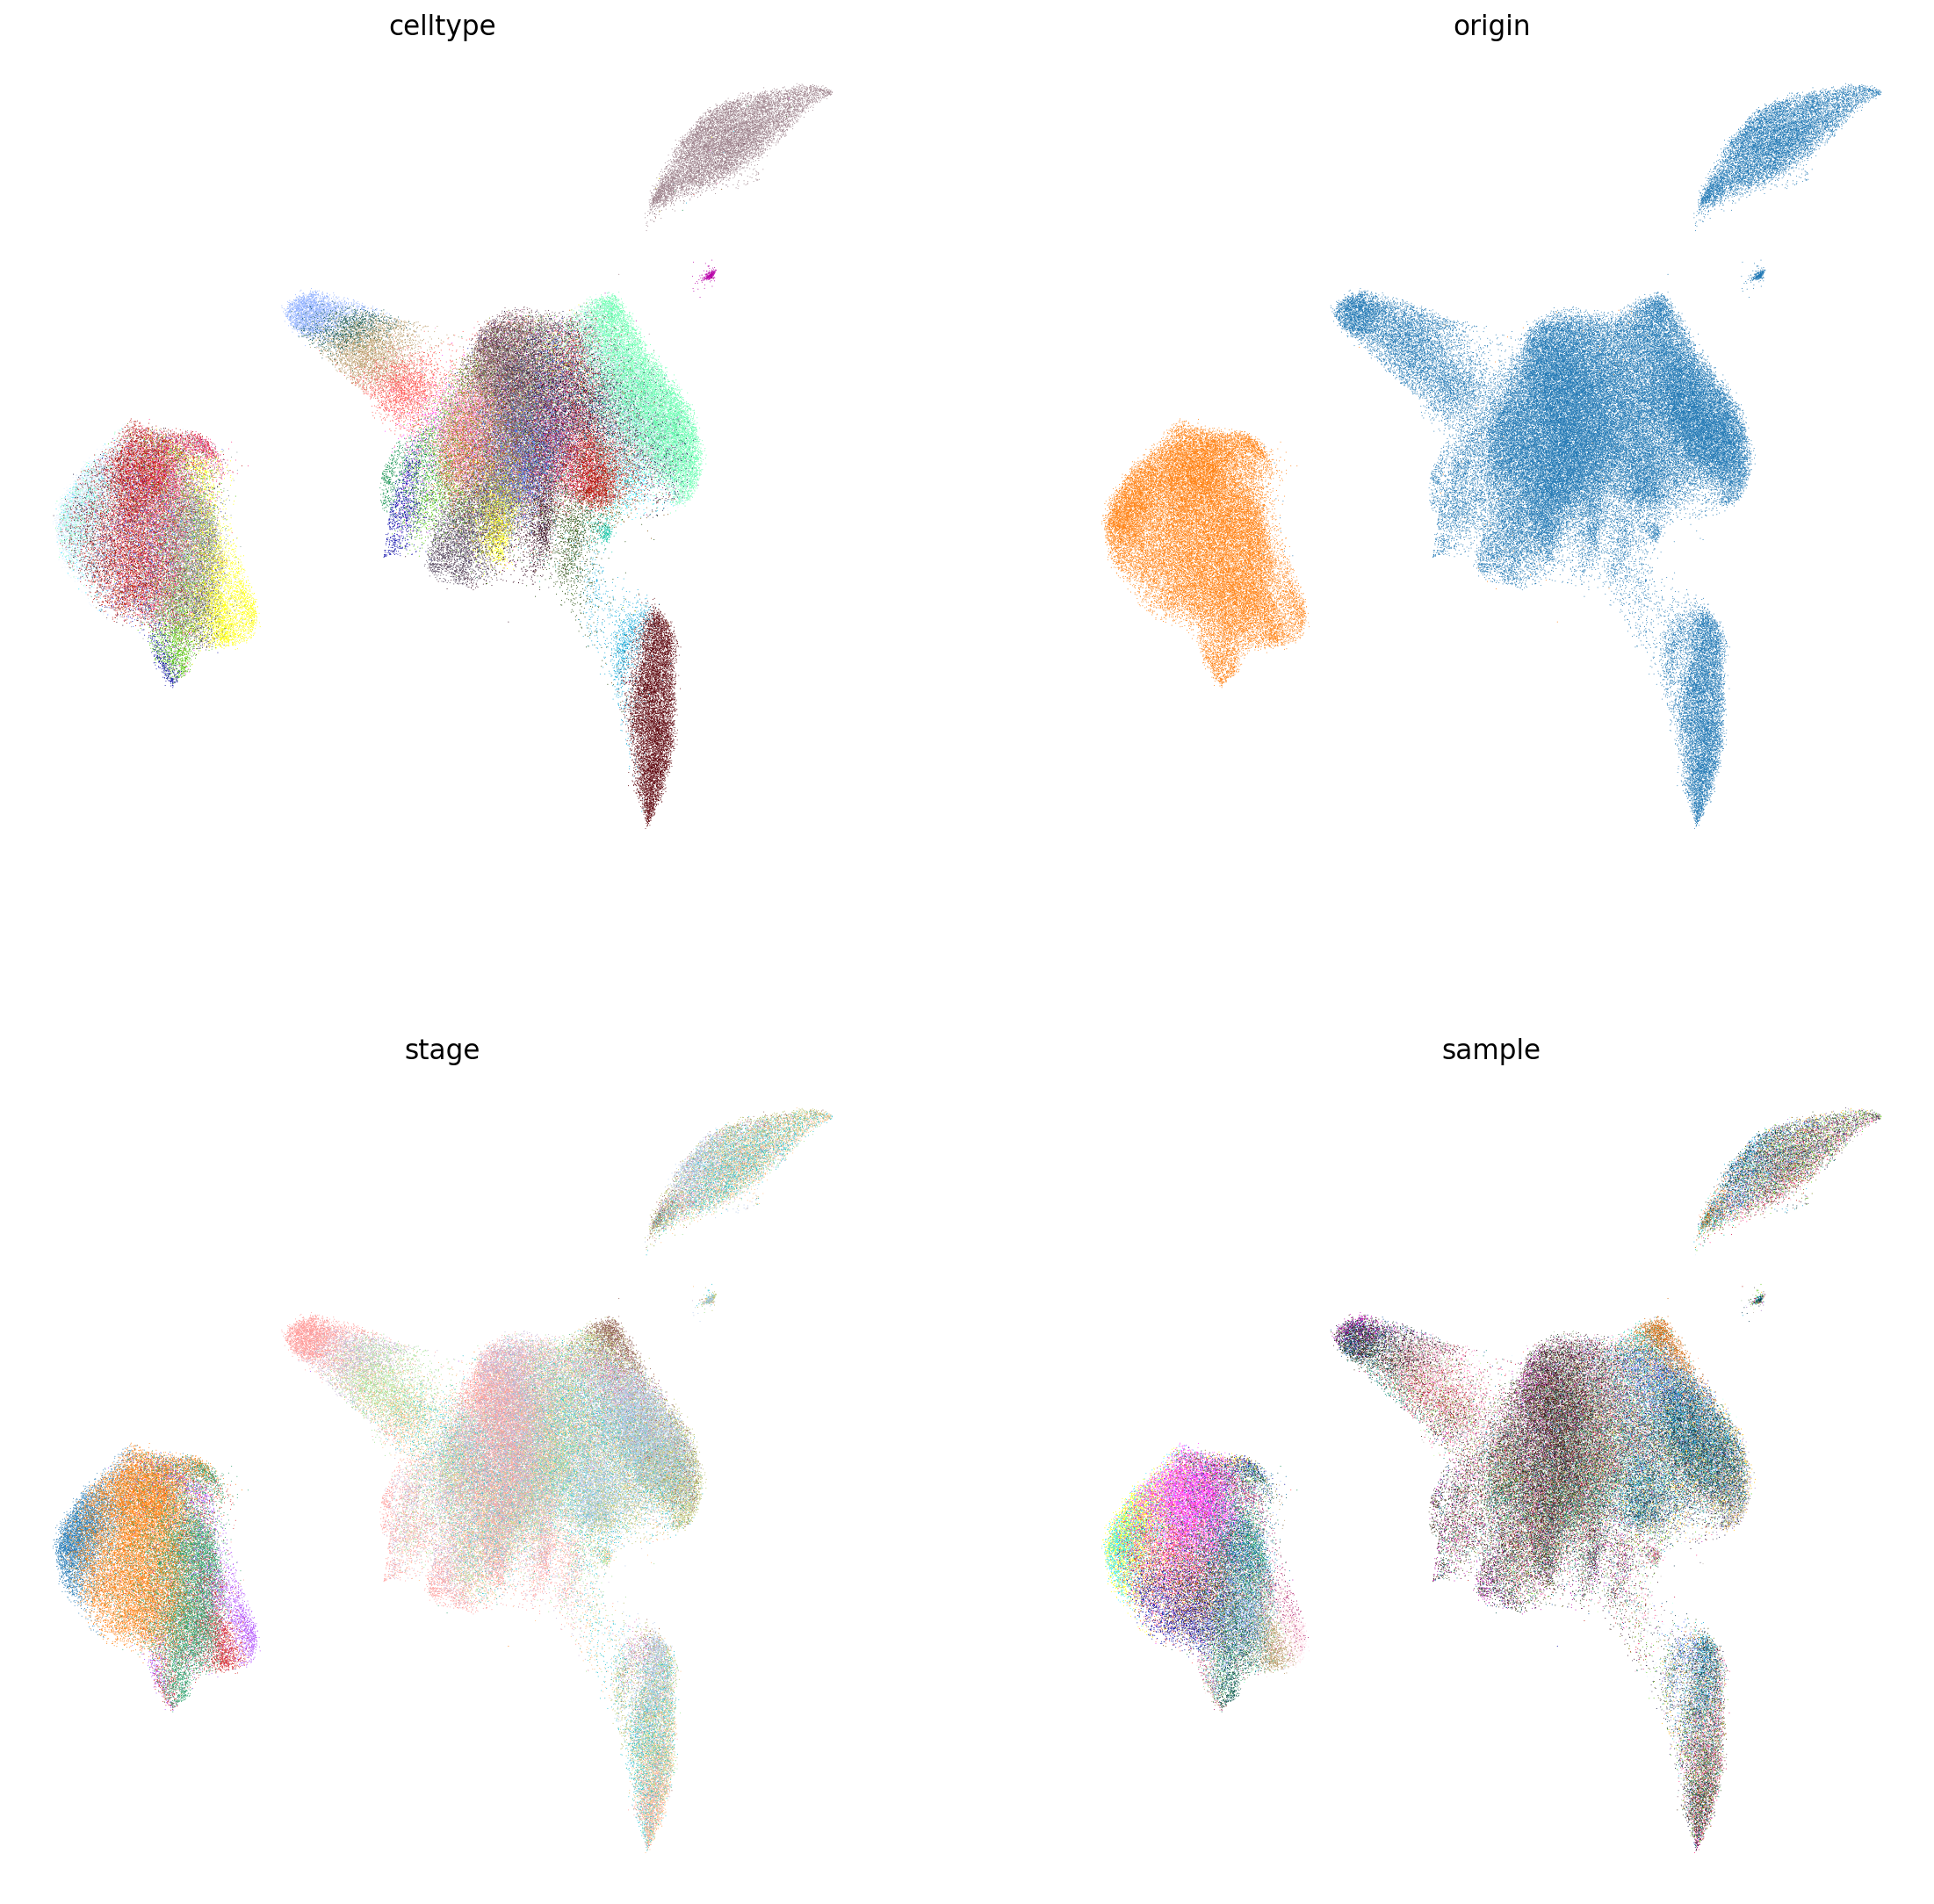

In [9]:
sc.pl.umap(
    adata,
    color=["celltype", "origin", "stage", "sample"],
    frameon=False,
    ncols=2, legend_loc='none',
    save = 'try1.png'
)

# Test 2

In [10]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="origin",
    categorical_covariate_keys=["stage", "sample"]
)

INFO     Using batches from adata.obs["origin"]                                              
INFO     No label_key inputted, assuming all cells have same label                           
INFO     Using data from adata.layers["counts"]                                              
INFO     Successfully registered anndata object containing 147203 cells, 2500 vars, 2        
         batches, 1 labels, and 0 proteins. Also registered 2 extra categorical covariates   
         and 0 extra continuous covariates.                                                  
INFO     Please do not further modify adata until model is trained.                          


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:315: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [11]:
model = scvi.model.SCVI(adata, n_latent=40)

In [ ]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 10/54:  17%|█▋        | 9/54 [27:04<2:13:26, 177.93s/it, loss=1.1e+03, v_num=1]

In [ ]:
model.save("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/rna/mapping/scVI_test/scvi_model_try2/")

In [ ]:
model = scvi.model.SCVI.load("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/rna/mapping/scVI_test/scvi_model_try2/", adata)

In [ ]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent
# adata.layers["scvi_normalized"] = model.get_normalized_expression(
#     library_size=10e4
# )

In [ ]:
adata.obs.tail()

In [ ]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=35)
sc.tl.umap(adata, min_dist=0.4)

In [ ]:
sc.pl.umap(
    adata,
    color=["celltype", "origin", "stage", "sample"],
    frameon=False,
    ncols=2, legend_loc='none',
    save = 'try2.png'
)

# Test 3

In [ ]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="sample",
    categorical_covariate_keys=["stage", "origin"]
)

In [ ]:
model = scvi.model.SCVI(adata, n_latent=40)

In [ ]:
model.train()

In [ ]:
model.save("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/rna/mapping/scVI_test/scvi_model_try3/")

In [ ]:
model = scvi.model.SCVI.load("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/rna/mapping/scVI_test/scvi_model_try3/", adata)

In [ ]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent
# adata.layers["scvi_normalized"] = model.get_normalized_expression(
#     library_size=10e4
# )

In [ ]:
adata.obs.tail()

In [ ]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=35)
sc.tl.umap(adata, min_dist=0.4)

In [ ]:
sc.pl.umap(
    adata,
    color=["celltype", "origin", "stage", "sample"],
    frameon=False,
    ncols=2, legend_loc='none',
    save = 'try3.png'
)